**Project 8. Time Series Forecasting**


**Dataset:** `airline-passengers.csv`

To model and forecast monthly airline passenger demand using historical data to understand long term growth and recurring seasonal travel patterns.

>**Time series forecasting** predicts future values by learning patterns like trend and seasonality from historical, time ordered data.
Unlike regular ML, the order of data matters, and past values directly influence future predictions

In [40]:
# installing the dependencies
%pip install -q numpy pandas matplotlib statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# import required dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import(mean_squared_error, mean_absolute_error, root_mean_squared_error)

In [42]:
# load data
df = pd.read_csv("airline-passengers.csv")

In [43]:
df.shape

(144, 2)

In [44]:
display(df.head())

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [45]:
display(df.tail())

,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [47]:
# check missing values
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

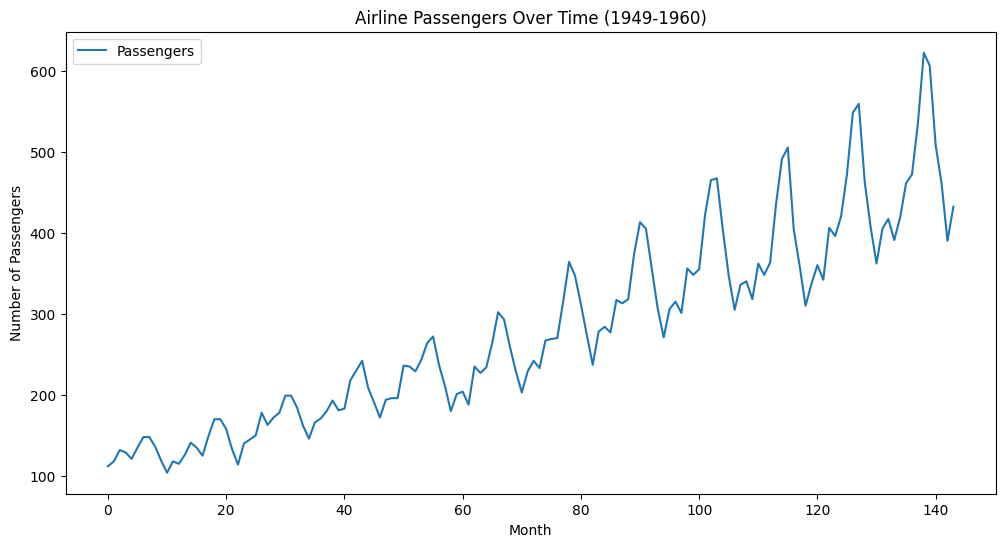

In [48]:
# plot time series data

plt.figure(figsize=(12, 6))
plt.plot(df["Passengers"], label="Passengers")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.title("Airline Passengers Over Time (1949-1960)")
plt.legend()
plt.show()

>Inference: Seasonality is clearly visible in the data

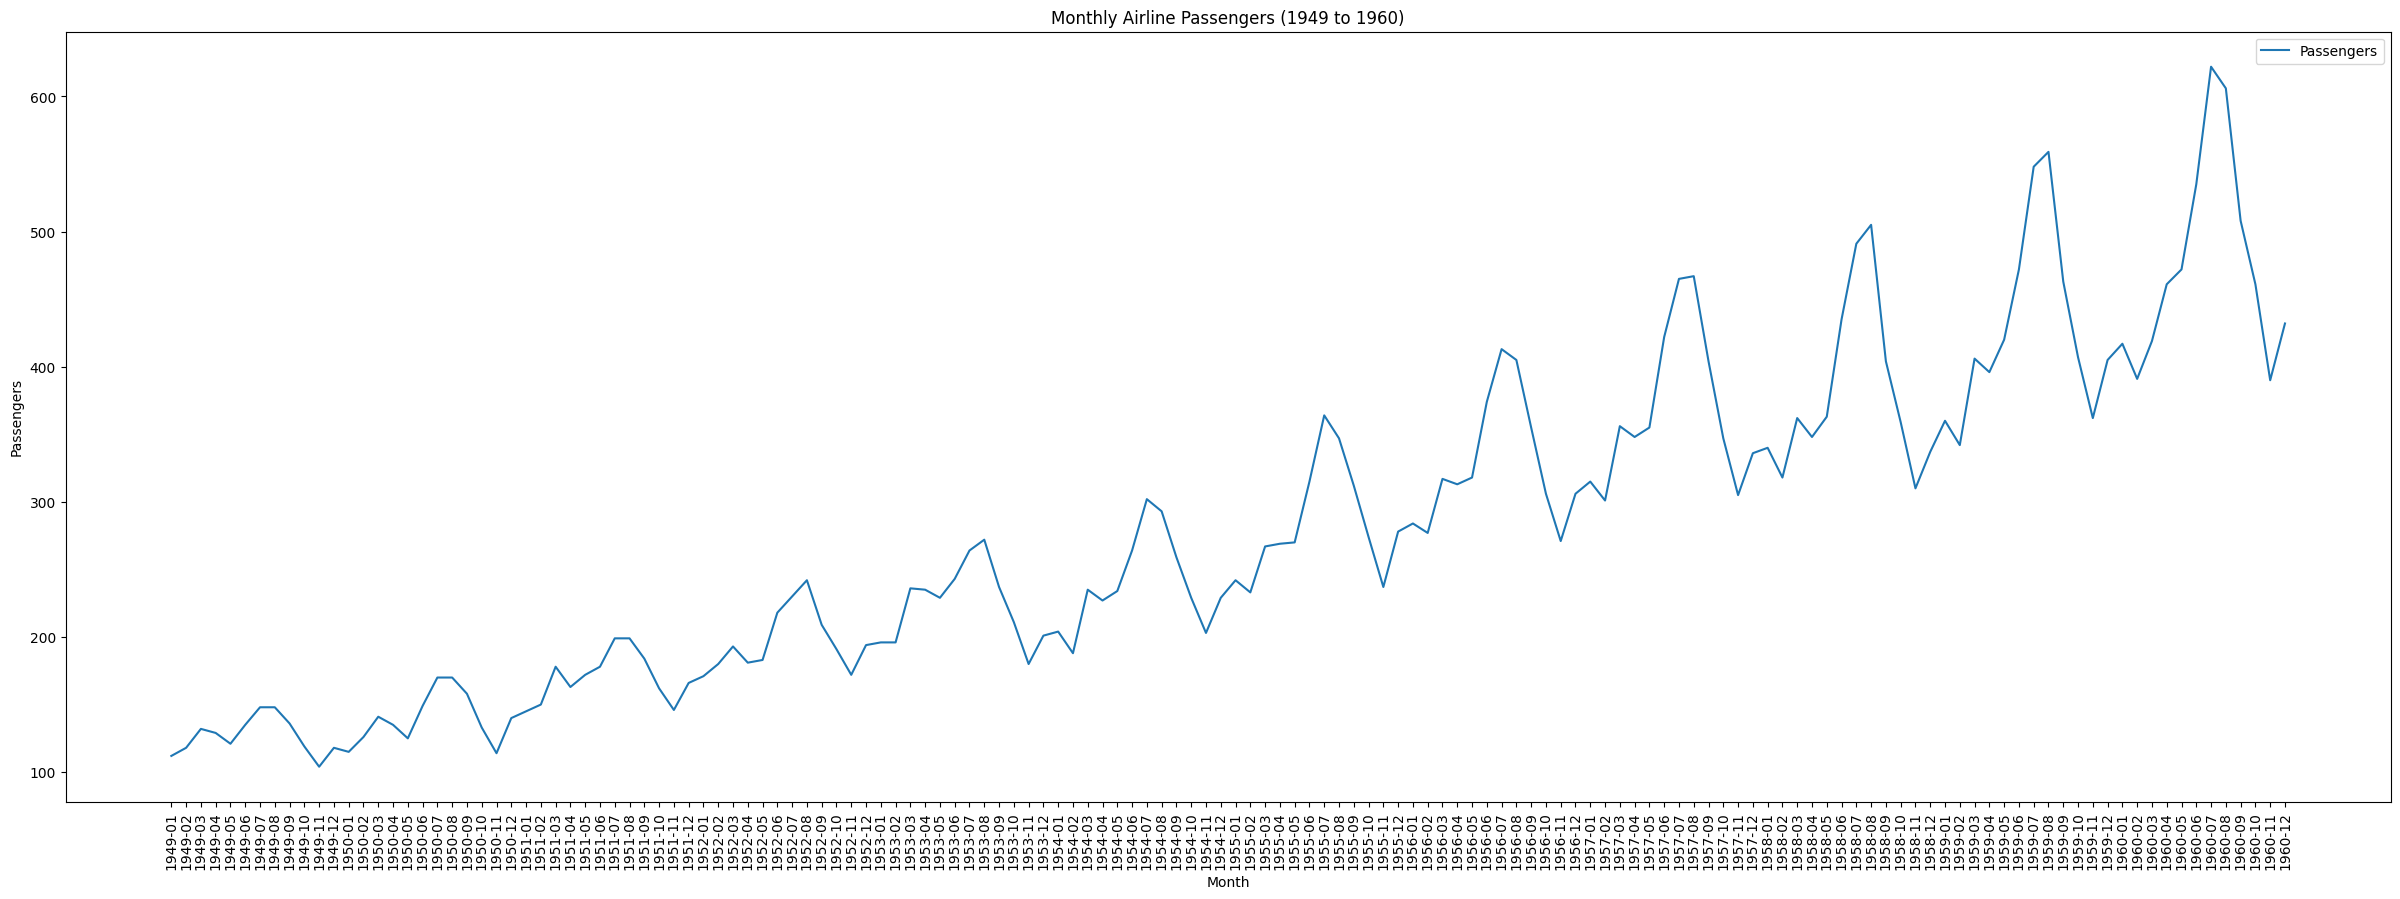

In [49]:
# plot time series
plt.figure(figsize=(30,10))
plt.plot(df["Month"], df["Passengers"], label="Passengers")
plt.title("Monthly Airline Passengers (1949 to 1960)")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.xticks(rotation="vertical")
plt.legend()
plt.show()

In [50]:
# check for non-stationary (seasonal) data using Augmented Dickey-Fuller test (adfuller)
result = adfuller(df["Passengers"])
p_value = result[1]
adf_value = result[0]
print(f"p-value: {p_value:.3f}")
print(f"ADF Stat: {adf_value:.3f}")

p-value: 0.992
ADF Stat: 0.815


Null Hypothesis (H0) -> The data is non-stationary (seasonal)

Alternate Hypothesis (H1) -> The data is stationary (non-seasonal)

- P-value > 0.05 then data is seasonal otherwise non-seasonal.
- ADF value is positive then data is seasonal, if negative then non - seasonal


>Inference: The high p-value shows the series is non stationary, so transformations like differencing or decomposition are required before forecasting.

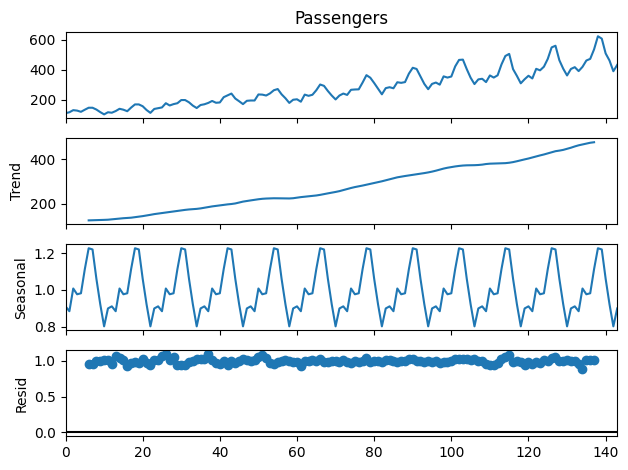

In [51]:
# seasonal decomposition
decomposition = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)
decomposition.plot()
plt.show()

In [52]:
# train test split
train = df.iloc[:-12]   # extract all the rows except last 12 rows
test = df.iloc[-12:]    # extract last 12 rows

In [53]:
train.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [54]:
test.head()

,Month,Passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472


In [55]:
# Train ARIMA model
model = ARIMA(train["Passengers"], order=(5, 1, 0))
trained_model = model.fit() 

In [56]:
# forecast 
forecast = trained_model.forecast(steps=12)

In [57]:
print("Forecasted values:")
print(forecast)

Forecasted values:
132    458.449443
133    479.570530
134    480.136848
135    456.665329
136    435.835310
137    431.734530
138    437.928972
139    448.935482
140    455.562127
141    454.628435
142    450.095385
143    445.706019
Name: predicted_mean, dtype: float64


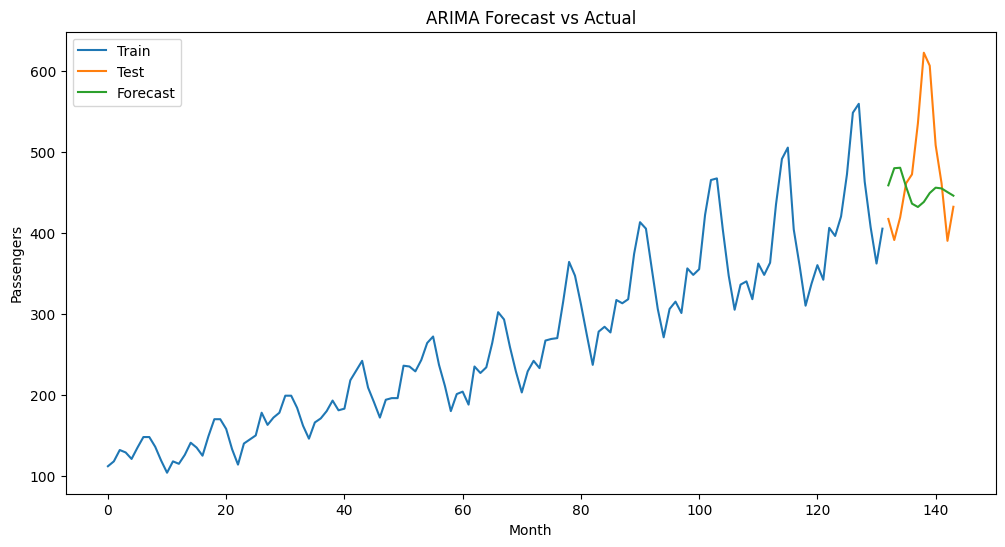

In [58]:
# plot forecast vs actual
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [59]:
# error metcrics
mse = mean_squared_error(test["Passengers"], forecast)
mae = mean_absolute_error(test["Passengers"], forecast)
rmse = root_mean_squared_error(test["Passengers"], forecast)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Squared Error: 7536.00
Mean Absolute Error: 67.39
Root Mean Squared Error: 86.81


In [60]:
# sarimax model
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [61]:
# get log values
train_log = np.log(train["Passengers"])
test_log = np.log(test["Passengers"])

In [62]:
sarimax_model = SARIMAX(train_log, order=(1,1,1), seasonal_order=(1,1,1,12))

In [63]:
# train the model
sarimax_trained_model = sarimax_model.fit()

In [64]:
forecast_log = sarimax_trained_model.forecast(steps=12)
forecast_sarimax = np.exp(forecast_log)

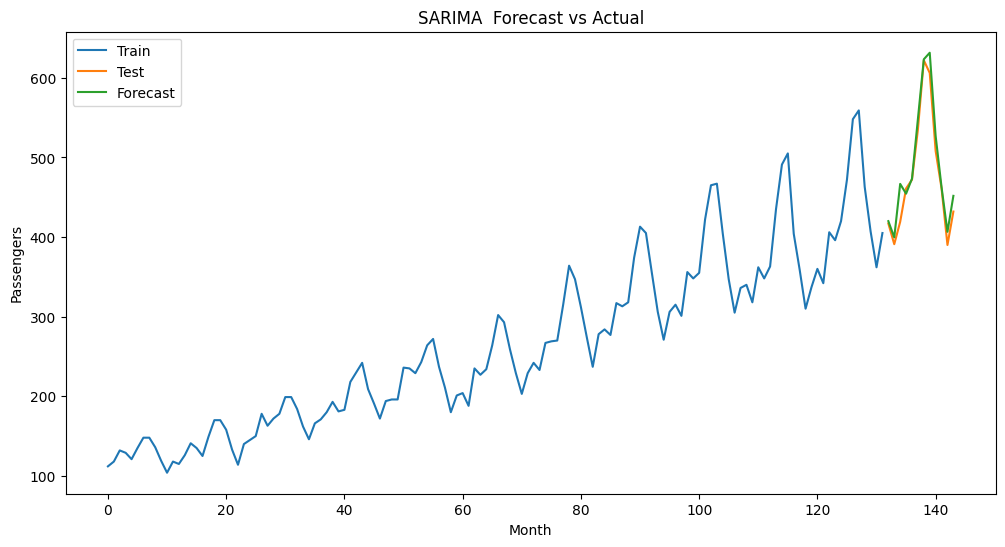

In [65]:
# plot forecast vs actual
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, forecast_sarimax, label="Forecast")
plt.title("SARIMA  Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [66]:
# error metcrics
mse = mean_squared_error(test["Passengers"], forecast_sarimax)
mae = mean_absolute_error(test["Passengers"], forecast_sarimax)
rmse = root_mean_squared_error(test["Passengers"], forecast_sarimax)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Squared Error: 354.57
Mean Absolute Error: 13.65
Root Mean Squared Error: 18.83


**ARIMA**

Full form: AutoRegressive Integrated Moving Average

One-liner: Predicts future values by removing trend and learning from past values and past errors.

(P, D, Q)
- P → past values used
- D → trend removal
- Q → past errors used

⸻

**SARIMAX**

Full form: Seasonal AutoRegressive Integrated Moving Average with eXogenous variables

One-liner: ARIMA extended to learn repeating seasonal patterns and optional external inputs.

Seasonal (P, D, Q, S)
- P, D, Q → seasonal memory and corrections
- S → season length (12 for monthly data)

⸻

Quick rule
- ARIMA → no seasonality
- SARIMAX → seasonality present